#### [PREV](3.OOP_Polynomial_Liner_Regression.ipynb) | [HOME](../README.md) | [NEXT](5.OOP_KNN.ipynb)

---

# OOP Logistic Regression Implementation

This Jupyter Notebook provides a basic implementation of Logistic Regression for categorisation. The data set contains measurements on a single species of insect captured on two continents. We want to predict an insects continent given the other measurements we have.

#### Step 1 - Import Dependencies

In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_absolute_error,mean_squared_error 

#### Step 2 - Import And Visualise The Data

In [2]:
#Import data as a Pandas DataFrame
insects = pd.read_csv('./data/insects.csv', sep='\t')
insects = pd.DataFrame({
    'continent': insects['continent'],
    'latitude': insects['latitude'],
    'sex': insects['sex'],
    'wingsize': insects['wingsize']
})

# Features variable
X_insects = insects[['wingsize', 'latitude', 'sex']]
# Target variable
y_insects = insects['continent']

insects.head()

,continent,latitude,sex,wingsize
0,1,35.5,0,901
1,1,37.0,0,896
2,1,38.6,0,906
3,1,40.7,0,907
4,1,40.9,0,898


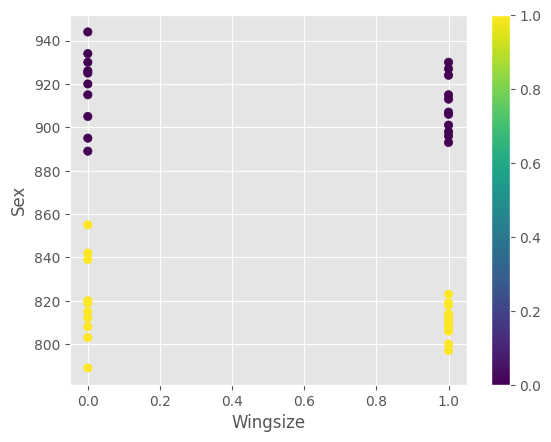

In [3]:
# Plot the data, colour coded by sex
ax = plt.scatter(insects.continent, insects.wingsize, c=insects['sex'])
plt.xlabel("Wingsize")
plt.ylabel("Sex")
plt.colorbar()
plt.show()

#### Step 3: Instantiate a LogisticRegression Object

In [4]:
insects_regression = LogisticRegression()

#### Step 4: Fit the model

In [5]:
insects_regression.fit(X_insects, y_insects)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

Now that the regression has been fit, we can use the `predict` method to forecast whether our model thinks a family will switch wells.

In [6]:
# Predict the target for the whole dataset
insects_predictions = insects_regression.predict(X_insects)

#Predict the target for a new data point
new_insect = pd.DataFrame({
    'wingsize': [1],
    'latitude': [40],
    'sex': [0]
})
new_insect['continent'] = insects_regression.predict(new_insect)
print(f"New insect is:\n{new_insect}")

New insect is:
   wingsize  latitude  sex  continent
0         1        40    0          1


Additionally (and in many cases more usefully), the `LogisticRegression` has a `predict_proba` method that produces a predicted **probability**.

In [7]:
#Predict the probabilities for the whole dataset
insects_probabilities = insects_regression.predict_proba(X_insects)

#Predict the probabilities for a new data point
new_insect = pd.DataFrame({
    'wingsize': [1],
    'latitude': [40],
    'sex': [0]
})
new_insect_probabilities = insects_regression.predict_proba(new_insect)
print(f"Probabilities for new insect are:\n{new_insect_probabilities}")

Probabilities for new insect are:
[[0.00675163 0.99324837]]


#### Step 5: Plot the Predictions

Text(0, 0.5, 'Continent Prediction')

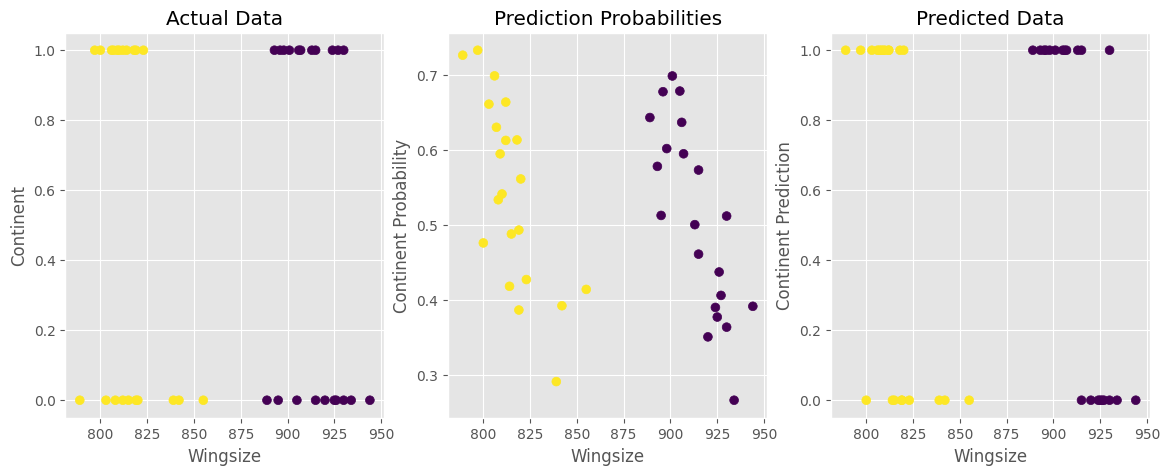

In [8]:
#Plot the predictions compared to the actual data
fig, axs = plt.subplots(1, 3, figsize=(14, 5))

axs[0].scatter(insects.wingsize, insects.continent, s=40, c=insects['sex'])
axs[0].set_title("Actual Data")
axs[0].set_xlabel("Wingsize")
axs[0].set_ylabel("Continent")

axs[1].scatter(insects.wingsize, insects_probabilities[:, 1], s=40, c=insects['sex'])
axs[1].set_title("Prediction Probabilities")
axs[1].set_xlabel("Wingsize")
axs[1].set_ylabel("Continent Probability")

axs[2].scatter(insects.wingsize, insects_predictions, s=40, c=insects['sex'])
axs[2].set_title("Predicted Data")
axs[2].set_xlabel("Wingsize")
axs[2].set_ylabel("Continent Prediction")

#### Step 6: Evaluate The Model

In [9]:
mae = mean_absolute_error(y_true=y_insects,y_pred=insects_probabilities[:, 1]) 
mse = mean_squared_error(y_true=y_insects,y_pred=insects_probabilities[:, 1])
print("MAE:",mae) 
print("MSE:",mse)

MAE: 0.46688397982193086
MSE: 0.2327758162300856


In [10]:
#Optional: Manually Evaluate the loss and cost of the model
model_loss = pd.DataFrame({
    'Target': y_insects,
    'Predicted result': insects_probabilities[:, 1],
    'Loss': abs(insects_regression.predict(X_insects).round(2) - y_insects)**2
})
model_loss["Predicted result"] = model_loss["Predicted result"].round(0)
model_loss["Loss"] = model_loss["Loss"].abs()
model_cost = 1 / (2 * model_loss.shape[0]) * model_loss['Loss'].sum()

print(f"The cost of this model is  {model_cost:.5f}")
print(f"The model predicted incorrectly {model_loss['Loss'].sum()} times out of {model_loss.shape[0]} predictions")
print(model_loss)

The cost of this model is  0.21429
The model predicted incorrectly 18 times out of 42 predictions
    Target  Predicted result  Loss
0        1               1.0     0
1        1               1.0     0
2        1               1.0     0
3        1               1.0     0
4        1               1.0     0
5        1               1.0     0
6        1               1.0     0
7        1               0.0     1
8        1               0.0     1
9        1               0.0     1
10       1               0.0     1
11       0               1.0     1
12       0               1.0     1
13       0               1.0     1
14       0               1.0     1
15       0               1.0     1
16       0               0.0     0
17       0               0.0     0
18       0               0.0     0
19       0               0.0     0
20       0               0.0     0
21       1               1.0     0
22       1               1.0     0
23       1               1.0     0
24       1               1.